In [73]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

Data Gabungan 2023-2024

In [74]:
Clust_data = pd.read_excel('D:/Kerjaan/Project P64180125 (k-Means, DBSCAN and TOPSIS in Python)/Post Revisi/Clustering Data Frame.xlsx',index_col=0)

In [75]:
# Delete rows that contains NaN
Clust_data = Clust_data.dropna()
Clust_data.head()

# Mengganti "-" dengan 0
Clust_data = Clust_data.replace('-', 0)

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_8544\931662291.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data = data.replace('-', 0)


In [76]:
# Define the data
X = Clust_data.iloc[:,1:].values
X

array([[0.0000e+00, 0.0000e+00, 0.0000e+00, ..., 6.8280e+01, 1.6692e+04,
        1.1501e+04],
       [6.0000e+00, 5.7200e+02, 8.3700e+02, ..., 2.9754e+02, 1.9580e+04,
        1.1784e+04],
       [0.0000e+00, 0.0000e+00, 0.0000e+00, ..., 1.6332e+02, 1.5512e+04,
        8.4960e+03],
       ...,
       [7.0000e+00, 1.4000e+02, 2.4200e+02, ..., 1.6726e+02, 2.0009e+04,
        7.6000e+03],
       [1.0000e+00, 4.5000e+01, 6.7000e+01, ..., 1.7837e+02, 1.8312e+04,
        8.4580e+03],
       [0.0000e+00, 0.0000e+00, 0.0000e+00, ..., 9.8390e+01, 1.9250e+04,
        7.0010e+03]])

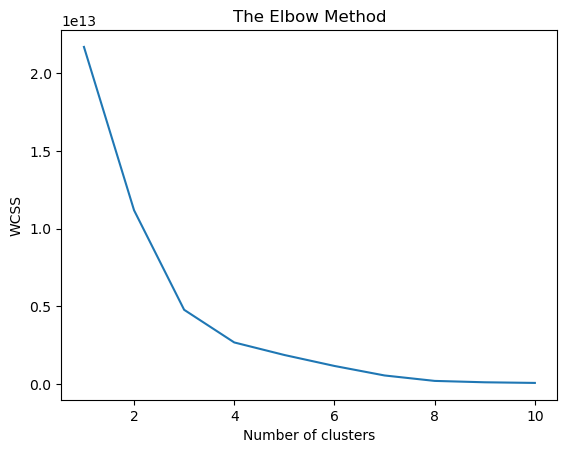

In [77]:
# Using the elbow method to find the optimal number of clusters
wcss =[]
for i in range (1,11):
    kmeans = KMeans(n_clusters = i, init = 'k-means++', max_iter =300, n_init = 10, random_state = 0)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

# Plot the graph to visualize the Elbow Method to find the optimal number of cluster
plt.plot(range(1,11),wcss)
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

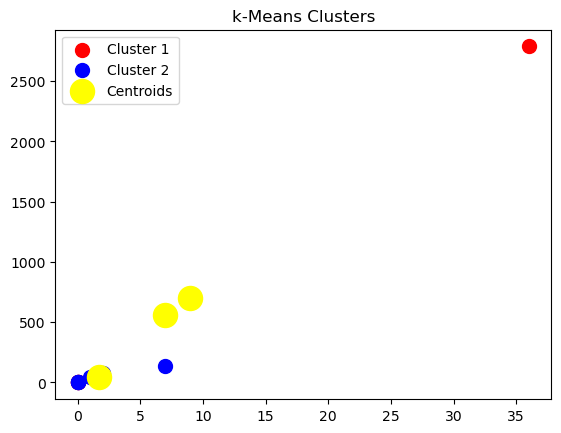

In [78]:
# K-Means Clustering
kmeans=KMeans(n_clusters= 3, init = 'k-means++', max_iter = 300, n_init = 10, random_state = 0)
Y_Kmeans = kmeans.fit_predict(X)

# Visualising the clusters
plt.scatter(X[Y_Kmeans == 0, 0], X[Y_Kmeans == 0,1],s = 100, c='red', label = 'Cluster 1')
plt.scatter(X[Y_Kmeans == 1, 0], X[Y_Kmeans == 1,1],s = 100, c='blue', label = 'Cluster 2')
plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], s = 300, c = 'yellow', label = 'Centroids')
plt.title('k-Means Clusters')
plt.legend()
plt.show()

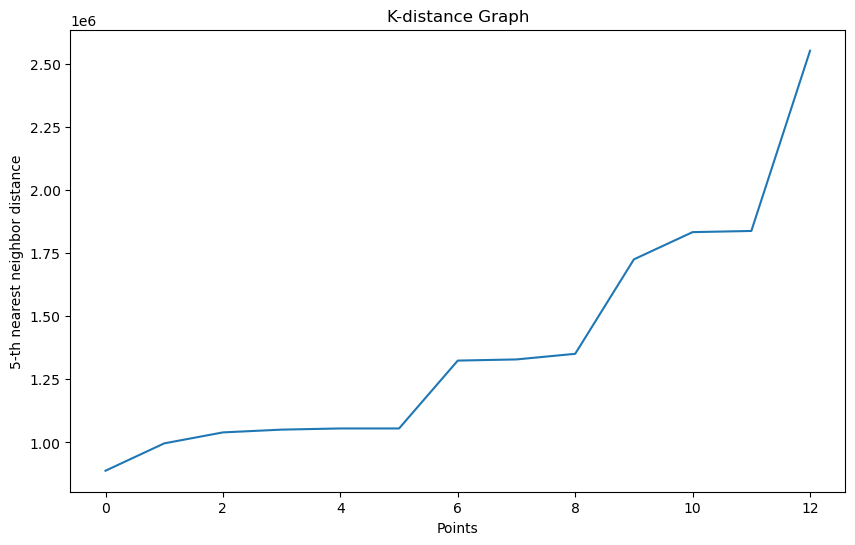

In [79]:
# Function to plot k-distance graph
def plot_k_distance_graph(X, k):
    neigh = NearestNeighbors(n_neighbors=k)
    neigh.fit(X)
    distances, _ = neigh.kneighbors(X)
    distances = np.sort(distances[:, k-1])
    plt.figure(figsize=(10, 6))
    plt.plot(distances)
    plt.xlabel('Points')
    plt.ylabel(f'{k}-th nearest neighbor distance')
    plt.title('K-distance Graph')
    plt.show()
# Plot k-distance graph
plot_k_distance_graph(X, k=5)

In [81]:
# Perform DBSCAN clustering
# Find optimal min_samples using Silhouette analysis
best_min_samples = 2  # Initialize
best_silhouette_score = -1

for min_samples in range(2, 101): # Test a range of min_samples
  dbscan = DBSCAN(eps=1, min_samples=min_samples) # Use the epsilon determined previously
  clusters = dbscan.fit_predict(X)

  # Check if the clustering resulted in more than one cluster and no all points are noise
  if len(set(clusters)) > 1 and -1 not in clusters or list(clusters).count(-1) < len(clusters):
    silhouette_avg = silhouette_score(X, clusters)
    if silhouette_avg > best_silhouette_score:
      best_silhouette_score = silhouette_avg
      best_min_samples = min_samples

print(f"Optimal min_samples based on Silhouette Score: {best_min_samples}")

# Perform DBSCAN clustering with the optimal min_samples
dbscan = DBSCAN(eps=1, min_samples=best_min_samples)
clusters = dbscan.fit_predict(X)

Optimal min_samples based on Silhouette Score: 2


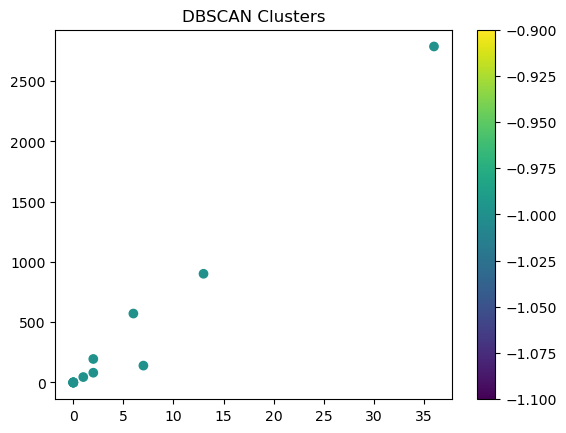

In [82]:
# Visualize the results
scatter = plt.scatter(X[:, 0], X[:, 1], c=clusters, cmap='viridis')
plt.colorbar(scatter)
plt.title('DBSCAN Clusters')
plt.show()

In [83]:
# Print number of clusters and noise points
n_clusters = len(set(clusters)) - (1 if -1 in clusters else 0)
n_noise = list(clusters).count(-1)
print(f'Number of clusters: {n_clusters+1}')
print(f'Number of noise points: {n_noise}')

Number of clusters: 1
Number of noise points: 13


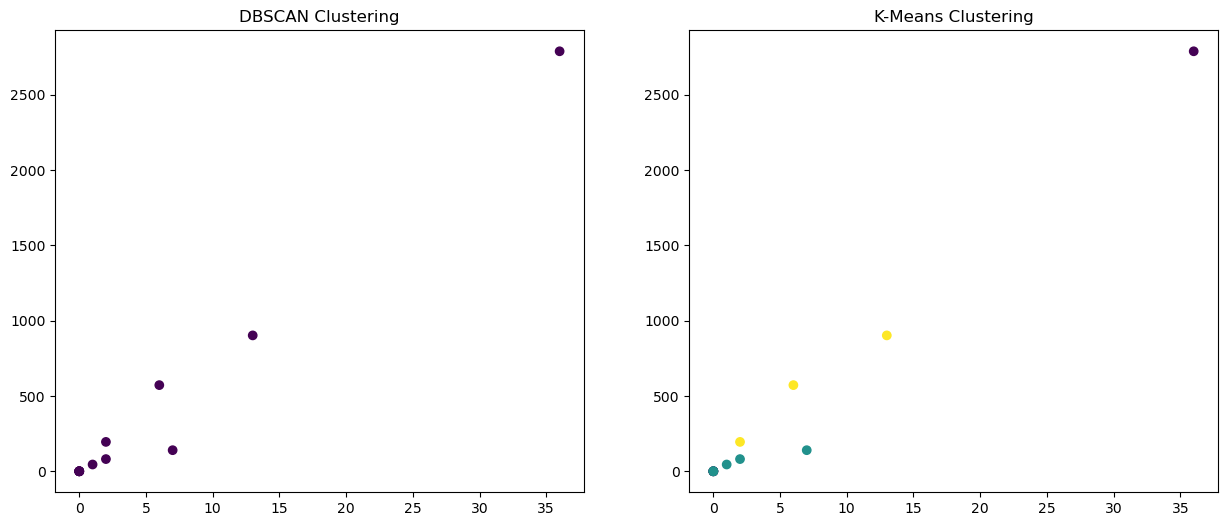

In [84]:
# DBSCAN clustering
dbscan = DBSCAN(eps=1, min_samples=2)
dbscan_labels = dbscan.fit_predict(X)

# K-Means clustering
kmeans = KMeans(n_clusters=3, random_state=0)
kmeans_labels = kmeans.fit_predict(X)

# Visualize the results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
ax1.scatter(X[:, 0], X[:, 1], c=dbscan_labels, cmap='viridis')
ax1.set_title('DBSCAN Clustering')
ax2.scatter(X[:, 0], X[:, 1], c=kmeans_labels, cmap='viridis')
ax2.set_title('K-Means Clustering')
plt.show()

In [85]:
from sklearn.metrics import silhouette_score

# Calculate Silhouette Score for K-Means
silhouette_kmeans = silhouette_score(X, kmeans_labels)
print(f"Silhouette Score for K-Means: {silhouette_kmeans}")

# Calculate Silhouette Score for DBSCAN
silhouette_dbscan = best_silhouette_score
print(f"Silhouette Score for DBSCAN: {silhouette_dbscan}")

# Compare the scores
if silhouette_kmeans > silhouette_dbscan:
    print("K-Means is the better clustering method based on Silhouette Score.")
elif silhouette_dbscan > silhouette_kmeans:
    print("DBSCAN is the better clustering method based on Silhouette Score.")
else:
    print("Both K-Means and DBSCAN have similar Silhouette Scores.")

Silhouette Score for K-Means: 0.5258017591888331
Silhouette Score for DBSCAN: -1
K-Means is the better clustering method based on Silhouette Score.


TOPSIS

In [86]:
# Calculate the mean of each feature for each cluster
cluster_means = []
for i in range(len(kmeans.cluster_centers_)):
    cluster_data = X[kmeans_labels == i]
    cluster_means.append(np.mean(cluster_data, axis=0))

criteria_weight = np.array(cluster_means)

# Criteria preference can be set based on domain knowledge or cluster characteristics
criteria_preference = np.ones(X.shape[1])

In [87]:
criteria_matrix = X

In [88]:
criteria_matrix = np.array(criteria_matrix, dtype=np.float64)
column_sums = (criteria_matrix ** 2).sum(axis=0)
with np.errstate(divide='ignore', invalid='ignore'): # Suppress warnings for division by zero
    norm_matrix = criteria_matrix / np.sqrt(column_sums)
    norm_matrix = np.nan_to_num(norm_matrix) #Handle NaN values resulting from division by zero

In [89]:
def weighted_matrix(criteria_weight, normalized_matrix):
    normalized_rows = len(normalized_matrix)
    normalized_columns = len(normalized_matrix[0])

    weighted_matrix = []
    for i in range(normalized_rows):
        weighted_matrix_rows = []
        for j in range(normalized_columns):
            weighted_matrix_rows.append(normalized_matrix [i][j]* criteria_weight[j])
        weighted_matrix.append(weighted_matrix_rows)

    print('\nWeighted matrix from normalized matrix: ')
    for i in weighted_matrix:
        for j in i:
            print(f'{j:.4f}',end=' ')
        print()
    return weighted_matrix

In [90]:
weighted_matrix_1 = weighted_matrix(criteria_weight[0].flatten(),norm_matrix)
weighted_matrix_2 = weighted_matrix(criteria_weight[1].flatten(),norm_matrix)
weighted_matrix_3 = weighted_matrix(criteria_weight[2].flatten(),norm_matrix)


Weighted matrix from normalized matrix: 
0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.1443 0.0000 2.3774 0.0000 0.2599 0.0000 0.0000 0.0000 0.0000 0.2606 56.0255 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 41.0583 0.0000 0.0000 0.2592 0.0000 1.1772 0.0000 0.0000 0.0000 0.0000 10.3114 0.7708 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.6395 0.0000 0.0000 0.0000 0.0000 0.0000 2.7471 0.0000 0.0000 5.8114 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0524 0.0000 0.0000 0.0000 37.4829 7.2903 0.1414 3.1441 5.2479 34.6916 0.0000 0.0000 1.5510 0.8620 3235.3352 0.2917 1243.4689 3118.1041 0.0000 0.0000 2912.4862 926.6497 0.0000 11754.3464 0.0000 0.0000 3.6053 3.6255 0.1021 0.1233 0.0000 18.8845 18.6262 4136.9453 3657.9317 
1.3676 133.0430 197.6783 0.0000 0.0000 0.0000 0.0000 0.2415 0.0000 0.0000 0.0000 0.0000 2.0948 0.000

In [91]:
def ideal_best_worst(weighted_matrix,criteria_preferences):
    weighted_column = len(weighted_matrix[0])
    positive_ideal= []
    negative_ideal = []

    for j in range(weighted_column):
        max_value = weighted_matrix[0][j]
        min_value = weighted_matrix[0][j]

        for i in range(len(weighted_matrix)):
            if weighted_matrix[i][j] > max_value:
                max_value = weighted_matrix [i][j]
            if weighted_matrix[i][j] < min_value:
                min_value = weighted_matrix [i][j]
        if criteria_preferences[j] == 1:
            positive_ideal.append(max_value)
            negative_ideal.append(min_value)
        else:
            positive_ideal.append(min_value)
            negative_ideal.append(max_value)

    print('\nPositive ideal point for each column: ')
    for i in positive_ideal:
        print(f'{i:.4f}',end=' ')
    print()
    print('\nNegative ideal point for each column: ')
    for i in negative_ideal:
        print(f'{i:.4f}',end=' ')
    print()

    return positive_ideal, negative_ideal

In [92]:
ideal_1 = ideal_best_worst(weighted_matrix_1,criteria_preference)
ideal_2 = ideal_best_worst(weighted_matrix_2,criteria_preference)
ideal_3 = ideal_best_worst(weighted_matrix_3,criteria_preference)


Positive ideal point for each column: 
8.2058 648.4683 1101.9915 0.0000 3.7500 2.6430 15.5000 3.3813 2.2500 0.1768 0.2500 2.7500 6.2845 2.2500 12.7402 0.1667 0.9428 1.0211 0.4330 11.7394 7.3964 2.9755 28.5837 7.7500 1.2500 1.2019 1.2500 0.7819 133.3804 0.2500 0.1768 0.0000 2.4627 2.0000 13.9800 0.0000 80.2742 5.5663 0.2500 2.3324 12.1011 14.5967 0.1768 5.2500 1.8131 2.7387 33.0495 41.3684 0.1768 2.1875 6.0000 1.7693 252.0955 14.5000 0.5031 8.8928 2.2500 13.6352 0.6013 0.4472 12.0117 0.9701 4.2632 10.8716 2.1144 15.5000 1.1163 0.0000 8.7407 0.5000 0.0000 17.1573 5.0508 0.2500 2.2500 3.7500 0.7778 0.0000 0.7938 0.0000 21.9986 3.5000 5.4887 0.5500 0.0000 2.2500 0.2500 69.2360 34.7251 404.9278 26.2012 31.2998 52.3808 0.0000 0.0000 6.9149 19.4932 249372.6062 652.7700 3084.7260 9494.7463 24584.2770 0.0000 26575.4811 4237.8779 3179.7319 50659.8793 0.0000 0.0000 4.5458 7.2510 0.2041 0.9864 0.9701 90.4902 91.1535 5130.7837 4507.1341 

Negative ideal point for each column: 
0.0000 0.0000 0.0000

In [93]:
def separation_from_ideal_point(weighted_matrix,positive_ideal,negative_ideal):
    weighted_rows = len(weighted_matrix)
    positive_separation = []
    negative_separation = []

    for i in range(weighted_rows):
        pos_sep = 0
        neg_sep = 0
        for j in range(len(positive_ideal)):
            pos_sep += (weighted_matrix[i][j] - positive_ideal[j]) ** 2
            neg_sep += (weighted_matrix[i][j] - negative_ideal[j]) ** 2
        positive_separation.append(pos_sep ** 0.5)
        negative_separation.append(neg_sep ** 0.5)

    print('\nPositive separation: ')
    for i in (positive_separation):
        print(f'{i:.4f}')
    print('\nNegative separation: ')
    for i in (negative_separation):
        print(f'{i:.4f}')
    return positive_separation,negative_separation

In [94]:
separation_1 = separation_from_ideal_point(weighted_matrix_1,ideal_1[0],ideal_1[1])
separation_2 = separation_from_ideal_point(weighted_matrix_2,ideal_2[0],ideal_2[1])
separation_3 = separation_from_ideal_point(weighted_matrix_3,ideal_3[0],ideal_3[1])


Positive separation: 
251655.8604
93731.7817
240695.8074
231604.8471
237700.5926
248186.5151
94104.6896
166646.9992
188609.7062
47708.5192
190445.3648
211097.5436
124018.4139

Negative separation: 
12702.3464
168176.7256
37877.3070
28868.8328
18071.5460
11240.7770
175580.9848
91805.9623
81010.3258
247074.8155
66125.3394
46700.0840
136329.0042

Positive separation: 
1070246.0803
983942.1128
1064608.5087
617944.3087
1060861.6421
601962.9697
987173.5070
1017238.6362
394960.6581
973606.7474
611677.5654
579023.3654
239553.9249

Negative separation: 
27369.7683
302132.5399
42901.5875
521462.1899
31310.2633
572173.7533
312398.8811
163266.1192
786521.5248
441056.1705
483098.3529
541187.4104
998511.0527

Positive separation: 
1510952.0088
498474.1072
1445056.6254
1387680.4806
1423498.3816
1481701.8827
454547.0727
955575.5695
1151037.8818
94178.2294
1108875.8917
1251862.1199
686939.7816

Negative separation: 
28226.3394
1019852.4124
70746.4672
126070.4458
90238.4918
32427.8106
1074131.1257
5613

In [95]:
def similarities_to_PIS(positive_separation,negative_separation):
    num_rows = len(positive_separation)
    relative_similarity = []

    for i in range(num_rows):
        pos_sep = positive_separation[i]
        neg_sep = negative_separation[i]
        similarity = neg_sep/(pos_sep + neg_sep)
        relative_similarity.append(similarity)

    print('\nOrder: ')
    for i in (relative_similarity):
        print(f'{i:.4f}')
    return relative_similarity

In [96]:
similarity_1 = similarities_to_PIS(separation_1[0],separation_1[1])


Order: 
0.0480
0.6421
0.1360
0.1108
0.0707
0.0433
0.6511
0.3552
0.3005
0.8382
0.2577
0.1812
0.5236


In [97]:
data_topsis_clust1 = pd.DataFrame({
    'KABKOT': data['KABKOT'],
    'Preferensi':similarity_1
})
data_topsis_clust1

,KABKOT,Order
0,BALANGAN,0.048050
1,BANJAR,0.642120
2,BARITO KUALA,0.135969
3,HULU SUNGAI SELATAN,0.110832
4,HULU SUNGAI TENGAH,0.070655
5,HULU SUNGAI UTARA,0.043329
6,KOTA BANJARBARU,0.651058
7,KOTA BANJARMASIN,0.355213
8,KOTABARU,0.300461
9,TABALONG,0.838157


In [71]:
similarity_2 = similarities_to_PIS(separation_2[0],separation_2[1])


Order: 
0.0249
0.2349
0.0387
0.4577
0.0287
0.4873
0.2404
0.1383
0.6657
0.3118
0.4413
0.4831
0.8065


In [72]:
data_topsis_clust2 = pd.DataFrame({
    'KABKOT': data['KABKOT'],
    'Preferensi':similarity_2
})
data_topsis_clust2

,KABKOT,Order
0,BALANGAN,0.024936
1,BANJAR,0.234926
2,BARITO KUALA,0.038737
3,HULU SUNGAI SELATAN,0.457661
4,HULU SUNGAI TENGAH,0.028668
5,HULU SUNGAI UTARA,0.487314
6,KOTA BANJARBARU,0.240386
7,KOTA BANJARMASIN,0.138302
8,KOTABARU,0.665707
9,TABALONG,0.311775


In [98]:
similarity_3 = similarities_to_PIS(separation_3[0],separation_3[1])


Order: 
0.0183
0.6717
0.0467
0.0833
0.0596
0.0214
0.7027
0.3701
0.2462
0.9412
0.2704
0.1735
0.5479


In [99]:
data_topsis_clust3 = pd.DataFrame({
    'KABKOT': data['KABKOT'],
    'Preferensi':similarity_3
})
data_topsis_clust3

,KABKOT,Order
0,BALANGAN,0.018339
1,BANJAR,0.671695
2,BARITO KUALA,0.046673
3,HULU SUNGAI SELATAN,0.083283
4,HULU SUNGAI TENGAH,0.059613
5,HULU SUNGAI UTARA,0.021417
6,KOTA BANJARBARU,0.702654
7,KOTA BANJARMASIN,0.370065
8,KOTABARU,0.246173
9,TABALONG,0.941182
